# Model Evaluation and Improvement

- Focus of the chapter is on supervised learning.
- Basic evaluation of supervised models:
  - Split data to training and test sets
  - Fit the model on training set
  - Use the `score` method to evaluate on the test set. For classification, the score is the fraction of correctly classified samples. For regression, the score is the coefficient of determination $R^2$

In [32]:
# Standard imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import mglearn

%matplotlib inline

In [15]:
# Example of evaluating a classification model using the score method
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_blobs

regressor = LogisticRegression()

# Create synthetic data set
X, y = make_blobs(random_state=0, centers=2)
X_train, X_test, y_train, y_test = train_test_split(X, y) # split data to training and test sets

# Fit model on training set
regressor.fit(X_train, y_train)

# Determine the score using the `score` method
print('Test score: {:.2f}'.format(regressor.score(X_test, y_test)))

Test score: 0.96


Topics to discuss in the chapter:
- **Cross validation.** a more robust way to assess generalization performance
- Methods of performance evaluation other than `score()`
- **Grid search** for hyperparameter tuning


## Cross-Validation

The most commonly used type is **$k$-fold cross validation**.

### $k$-Fold Cross Validation
1. Data is divided into $k$ folds
2. fold $2$ to fold $k$ will be used as training set and fold $1$ will be used as test set
3. Test score is computed for fold $1$
4. Repeat steps 2 to 3 for each fold

In [197]:
# Example of using k-fold cross-validation
from sklearn.model_selection import cross_val_score
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression

# Instantiate logistic regression model
regressor = LogisticRegression(max_iter=200)

# Load data set
iris = load_iris()
X = iris.data
y = iris.target

# Five-fold cross validation
scores = cross_val_score(regressor, X, y)

# Print scores
print('Cross validation scores:')
for i, score in enumerate(scores):
    print(f' Fold {i}: {score:.3f}')
print('------------------------')
print(' Average score: {:.3f}'.format(scores.mean()))

Cross validation scores:
 Fold 0: 0.967
 Fold 1: 1.000
 Fold 2: 0.933
 Fold 3: 0.967
 Fold 4: 1.000
------------------------
 Average score: 0.973


### Benefits of Cross-Validation
- Each sample is in the test set exactly once. So, how well the model generalizes is tested on all of the samples. On the other hand, `train_test_split` randomly splits the data, and the performance of the model may depend on the chance of getting "easy" test samples.
- It provides information on how sensitive a model is to the choice of training set.
- We utilize the data set more effectively, particularly for small datasets.

The main disadvantage is the increased computational cost: with $k$-fold cross-validation, we're now training and testing $k$ models.

**Important:** Cross-validation *does not* return a model. Its only purpose is to check how well an algorithm generalizes to a specific dataset.

### Stratified k-Fold Cross-Validation and Other Strategies

For classification tasks, it's not really a good idea to use standard cross-validation -- splitting the dataset into consecutive folds. This is true especially for sorted class labels.

In [187]:
print('Target variable of the Iris Data Set:\n', y)
print('\nSample count for each label:')
value_counts = np.unique_counts(y)
for label, count in zip(value_counts.values,value_counts.counts):
    print(f' label {label}: {count}')

Target variable of the Iris Data Set:
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]

Sample count for each label:
 label 0: 50
 label 1: 50
 label 2: 50


For the Iris data set, if we do a standard 3-fold cross validation, the folds will be as follows:
- Fold 1: First 50 samples, all samples have labels 0, the training set contains samples only with labels 1 or 2.
- Fold 2: Second 50 samples, all samples have labels 1, the training set contains samples only with labels 0 or 2.
- Fold 3: Last 50 samples, all have labels 2, training set contains samples only with labels 0 or 1.

In each fold, the model would learn only the two labels in the training set, and will be tested on samples with a label different from the training. So, the result will be a score of zero!

In [221]:
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize

rng = np.random.RandomState(1338)
cmap_data = plt.cm.winter
cmap_group = plt.cm.Spectral
cmap_cv = plt.cm.gray_r

def plot_cv_indices(cv, X, y, ax, n_splits, group=None, lw=10):
    """Create a sample plot for indices of a cross-validation object."""
    n_samples = X.shape[0]
    use_groups = "Group" in type(cv).__name__
    groups = group if use_groups else None
    # Generate the training/testing visualizations for each CV split
    for ii, (tr, tt) in enumerate(cv.split(X=X, y=y, groups=groups)):
        # Fill in indices with the training/test groups
        indices = np.array([np.nan] * len(X))
        indices[tt] = 1
        indices[tr] = 0

        # Visualize the results
        ax.scatter(
            range(len(indices)),
            [ii + 0.5] * len(indices),
            c=indices,
            marker="_",
            lw=lw,
            cmap=cmap_cv,
            vmin=-0.2,
            vmax=1.2,
        )

    # Plot of classes and group
    ax.scatter(
        range(len(X)),
        [ii + 1.5] * len(X),
        c=y,
        marker='_',
        lw=lw,
        cmap=cmap_data,
    )

    if group is not None:
        ax.scatter(
            range(len(X)),
            [ii + 2.5] * len(X),
            c=group,
            marker='_',
            lw=lw,
            cmap=cmap_group
        )

    # Add legend only for training set and test set
    norm = Normalize(vmin=-0.2, vmax=1.2)
    train_color = cmap_cv(norm(0))
    test_color = cmap_cv(norm(1))
    labels = np.unique(y)
    
    legend_elements = [
        Line2D(
            [0], [0],
            marker="_",
            color=train_color,
            markersize=20,
            linewidth=0,
            markeredgewidth=8,
            label="Training",
        ),
        Line2D(
            [0], [0],
            marker="_",
            color=test_color,
            markersize=20,
            linewidth=0,
            markeredgewidth=8,
            label="Test",
        ),
    ]
    
    ax.legend(handles=legend_elements, bbox_to_anchor=(1,1))
    
    # Formatting
    if group is not None:
        other_plots = ['class', 'group']
    else:
        other_plots = ['class']
        
    yticklabels = list(range(n_splits)) + other_plots
    ax.set(
        yticks=np.arange(n_splits + len(other_plots)) + 0.5,
        yticklabels=yticklabels,
        xlabel="Sample index",
        ylabel="CV iteration",
        ylim=[n_splits + len(other_plots) + 0.2, -0.2],
        xlim=[0, n_samples],
    )
    ax.set_title("{}".format(type(cv).__name__), fontsize=15)
    return ax

Standard 3-fold cross val scores:
 fold 1: 0.000
 fold 2: 0.000
 fold 3: 0.000


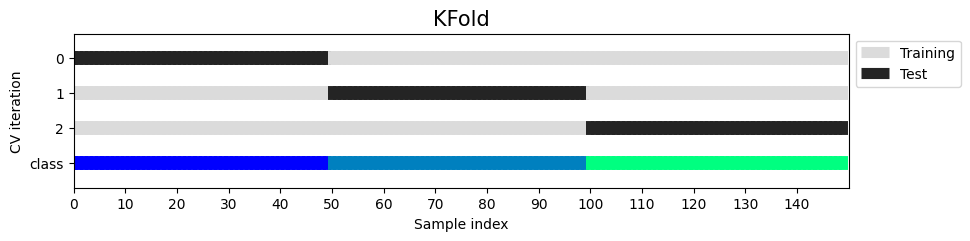

In [222]:
# Demonstration: Standard 3-fold classification on Iris dataset
from sklearn.model_selection import KFold

regressor = LogisticRegression(max_iter=200)
kfold = KFold(n_splits=3)
scores = cross_val_score(regressor, X, y, cv=kfold)

print('Standard 3-fold cross val scores:')
for i, score in enumerate(scores):
    print(f' fold {i+1}: {score:.3f}')


# Visualize split
fig,ax = plt.subplots(figsize=(10,2))
plot_cv_indices(kfold, X, y, ax, n_splits=3)
ax.set_xticks(np.arange(0,X.shape[0],10));

Instead of splitting data into consecutive folds for cross-validation, another way is to split so that the proportion between the labels is the same for each fold as they are in the whole data set. Cross-validation that implements this method of splitting is called **Stratified $k$-fold cross-validation**

For instance, for a data set with 2 classes, if 90% of the samples belong to the first class and 10% belong to the second, then, in each fold, 90% of the samples in the fold are from the first class, and 10% of the samples in the fold belong to the second. 

The proportion between classes in the whole data set is preserved in each fold.

For classification tasks, Scikit-learn's `cross_val_score` implements stratified cross-validation by default.

Stratified 3-fold cross val scores:
 Fold 0: 0.98
 Fold 1: 0.96
 Fold 2: 0.98


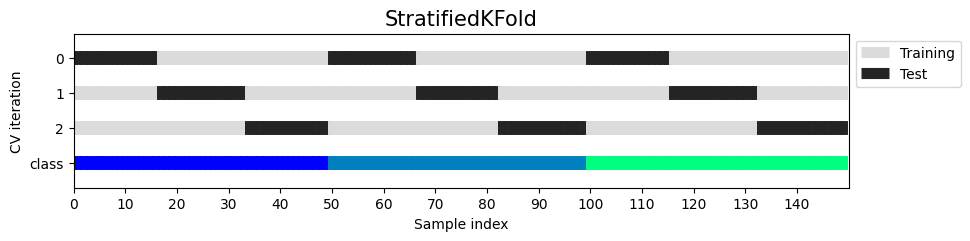

In [223]:
# Demonstration: Stratified k-fold cross validation on the Iris data set
from sklearn.model_selection import StratifiedKFold
stratified = StratifiedKFold(n_splits=3)
scores = cross_val_score(regressor, X, y, cv=stratified)
print('Stratified 3-fold cross val scores:')
for i, score in enumerate(scores):
    print(f' Fold {i}: {score}')

fig, ax = plt.subplots(figsize=(10,2))
plot_cv_indices(stratified, X, y, ax, 3)
ax.set_xticks(np.arange(0,X.shape[0],10));

#### Leave-one-out cross-validation

Another frequently used cross-validation method is **Leave-one-out**. This can be thought of as a $k$-fold cross-validation where each fold contains only one sample.

The training set in each iteration is the entire data set with one sample left out. The model is then tested on the sample that was left out.

There will be as much folds as there are samples. So, this method is more time-consuming especially for large datasets.

In [72]:
# Demonstration: Leave-one-out cross validation
from sklearn.model_selection import LeaveOneOut
loo = LeaveOneOut()
scores = cross_val_score(regressor, X, y, cv=loo)
print('Leave-one-out cross val score:')
print('  Number of iterations:', len(scores))
print('  Mean score: {:.3f}'.format(scores.mean()))

Leave-one-out cross val score:
  Number of iterations: 150
  Mean score: 0.967


#### Shuffle-split cross-validation

Another flexible strategy for cross-validation is **shuffle-split**.

Here, we specify the training size `train_size`, the test size `test_size`, and how many iterations/splits on the data `n_splits`. In each split, we take a random sample of `train_size` many points from the data set, and take another random sample for the test set (`test_size` many points) from the remaining points in the data set.

Shuffle-split cross val scores:
 Split 1: 0.933
 Split 2: 0.933
 Split 3: 0.987
 Split 4: 0.947
 Split 5: 0.960
 Split 6: 0.947
 Split 7: 0.973
 Split 8: 1.000
 Split 9: 0.960
 Split 10: 0.987


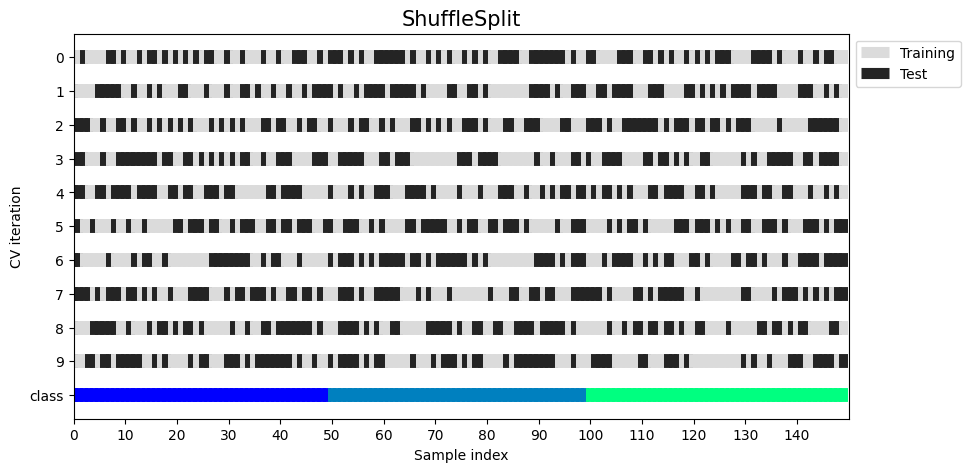

In [224]:
# Demonstration shuffle-split cross validation on the Iris data set
from sklearn.model_selection import ShuffleSplit

# To split the data set into 50% training set and 50% test set
# There are many ways to split the data 50-50. A consecutive split is a basic example (first 50% and last 50%)
# But the training set and test set need not be connected!
# Each subset can be generated by randomly picking out samples one-by-one until you get 50% of the total.
# Here only 10 of the possible ways to split the data 50-50 are considered

shuffle = ShuffleSplit(test_size=.5, train_size=.5, n_splits=10, random_state=0)

scores = cross_val_score(regressor, X, y, cv=shuffle)
print('Shuffle-split cross val scores:')
for i, score in enumerate(scores):
    print(f' Split {i+1}: {score:.3f}')

# Visualize
fig, ax = plt.subplots(figsize=(10,5))
plot_cv_indices(shuffle, X, y, ax, 10)
ax.set_xticks(np.arange(0,X.shape[0],10));

#### Cross-validation with groups

There are times where it is best to group the data prior to cross-validation so that samples of the same group are not split when generating the training and test sets in each CV iteration.

The groups are not to be confused with the labels!

Examples:
- The task is to identify emotions; the samples of the data set are pictures of 100 people, each of which appear in multiple samples. A stratified k-fold strategy could be used, but it is likely that images of the same person appear in both the training and test set. In that case, the classifier would have an easier time in detecting emotions. This is not ideal because we want to assess how good the classifier is in detecting emotions of new faces. So, we can group the image samples by person first so that they are not split when generating the training and test sets (here, labels = emotions, groups = people)

- Grouping is common in medical applications where multiple samples come from a single patient but we want the model to generalize to new patients.

- Speech recognition where there are multiple recordings of the same speaker, but we are interested in recognizing speech of new speakers.

GroupKFold cross val scores:
 Fold 0: 0.947
 Fold 1: 1.000
 Fold 2: 0.324


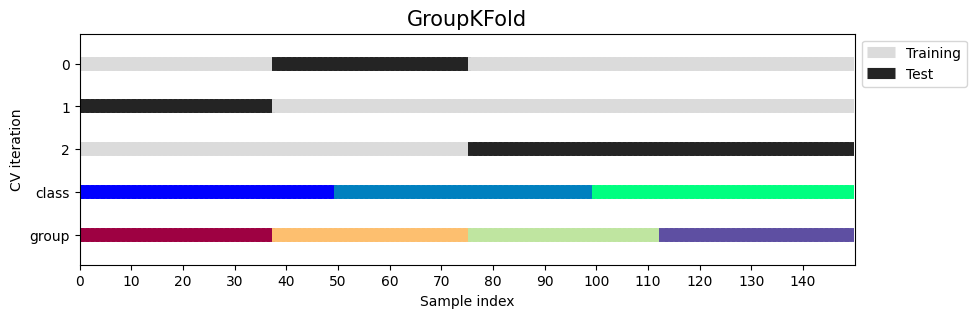

In [226]:
# Demonstration: cross val with groups
from sklearn.model_selection import GroupKFold

group_kfold = GroupKFold(n_splits=3)

# For demonstration purposes the iris data set will be grouped randomly
# Here we'll explicitly define the group for each sample
# First 38 samples are in group 0, second 38 samples are in group 1, and so on...
rng = np.random.default_rng()
group = np.hstack([
    np.full(38,0,dtype=int),
    np.full(38,1,dtype=int),
    np.full(37,2,dtype=int),
    np.full(37,3,dtype=int)
])

scores = cross_val_score(regressor, X, y, groups=group, cv=group_kfold)
print('GroupKFold cross val scores:')
for i, score in enumerate(scores):
    print(f' Fold {i}: {score:.3f}')

fig,ax = plt.subplots(figsize=(10,3))
plot_cv_indices(group_kfold, X, y, ax, n_splits=3, group=group)
ax.set_xticks(np.arange(0,len(X),10));

A better strategy for cross-validation with groups is the `StratifiedGroupKFold` where we'll attempt to preserve the proportion between the classes in the whole dataset in each CV iteration (stratified folds) while ensuring that the restriction of non-overlapping groups holds.

Stratified group cross val scores:
 Fold 0: 0.960
 Fold 1: 0.757
 Fold 2: 0.947


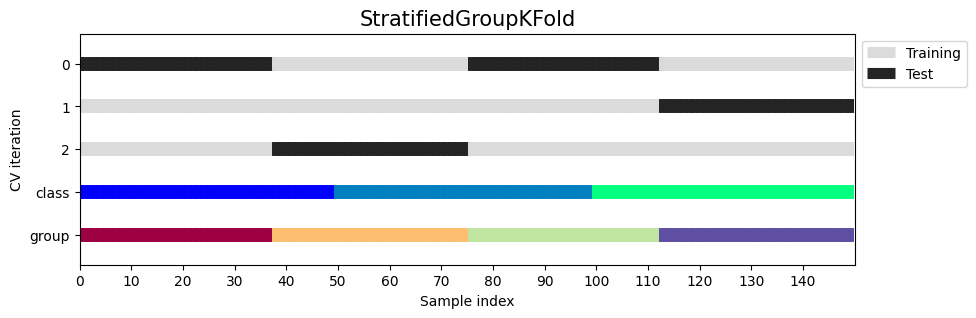

In [230]:
from sklearn.model_selection import StratifiedGroupKFold

group_stratified = StratifiedGroupKFold(n_splits=3)
scores = cross_val_score(regressor, X, y, groups=group, cv=group_stratified)
print("Stratified group cross val scores:")
for i, score in enumerate(scores):
    print(f' Fold {i}: {score:.3f}')

fig, ax = plt.subplots(figsize=(10,3))
plot_cv_indices(group_stratified, X, y, ax, n_splits=3, group=group)
ax.set_xticks(np.arange(0,len(X),10));

## Grid Search